In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer,HashingVectorizer
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [2]:
whatsapp_dataset=pd.read_csv("Preprocessed_whatsapp_data.csv")
whatsapp_dataset

,Date,Time,Name,Chat
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam
...,...,...,...,...
56,1/7/26,11:12 AM,Sathish Uma,Okay mam
57,1/7/26,12:31 PM,Rubhini Hope AI,I was in a other call... Reach you mam
58,1/7/26,3:24 PM,Sathish Uma,Sure Mam
59,1/7/26,3:29 PM,Sathish Uma,Got it Mam


In [3]:
whatsapp_dataset.dropna(inplace=True)

In [4]:
non_flirt_data=whatsapp_dataset[["Chat"]].copy()

In [5]:
non_flirt_data

,Chat
0,Hi Mam
1,I have completed the MCQ python test
2,I have some doubts in python interview questi...
3,https://github.com/Uma761995/Python-Debug/blo...
4,Python debugging set1 Mam
5,Fine! Hope you're fine
6,Okay mam
7,Sure Mam
8,Sure Mam
9,Yes Mam


In [6]:
non_flirt_data["Label"]="Non_Flirt"

In [7]:
non_flirt_data.head()

,Chat,Label
0,Hi Mam,Non_Flirt
1,I have completed the MCQ python test,Non_Flirt
2,I have some doubts in python interview questi...,Non_Flirt
3,https://github.com/Uma761995/Python-Debug/blo...,Non_Flirt
4,Python debugging set1 Mam,Non_Flirt


In [8]:
flirt_data = pd.read_csv("flirt_non_flirt_dataset.csv")

In [9]:
flirt_data.head()

,Chat,Label
0,You look beautiful today,Flirt
1,I miss talking to you,Flirt
2,Your smile is my favorite,Flirt
3,Are you always this charming?,Flirt
4,I can't stop thinking about you,Flirt


In [10]:
flirt_data=flirt_data[flirt_data["Label"]=="Flirt"]

In [11]:
flirt_data.head()

,Chat,Label
0,You look beautiful today,Flirt
1,I miss talking to you,Flirt
2,Your smile is my favorite,Flirt
3,Are you always this charming?,Flirt
4,I can't stop thinking about you,Flirt


In [12]:
dataset=pd.concat([non_flirt_data,flirt_data],ignore_index=True)

In [13]:
dataset

,Chat,Label
0,Hi Mam,Non_Flirt
1,I have completed the MCQ python test,Non_Flirt
2,I have some doubts in python interview questi...,Non_Flirt
3,https://github.com/Uma761995/Python-Debug/blo...,Non_Flirt
4,Python debugging set1 Mam,Non_Flirt
...,...,...
105,I hope I get to see you soon,Flirt
106,You make me feel special,Flirt
107,I like the way you look at me,Flirt
108,You are my favorite distraction,Flirt


In [14]:
dataset["Label"].value_counts()

Label
Non_Flirt    60
Flirt        50
Name: count, dtype: int64

In [15]:
dataset.drop_duplicates(inplace=True)

In [16]:
dataset

,Chat,Label
0,Hi Mam,Non_Flirt
1,I have completed the MCQ python test,Non_Flirt
2,I have some doubts in python interview questi...,Non_Flirt
3,https://github.com/Uma761995/Python-Debug/blo...,Non_Flirt
4,Python debugging set1 Mam,Non_Flirt
...,...,...
105,I hope I get to see you soon,Flirt
106,You make me feel special,Flirt
107,I like the way you look at me,Flirt
108,You are my favorite distraction,Flirt


In [17]:
dataset.reset_index(drop=True, inplace=True)

In [18]:
dataset

,Chat,Label
0,Hi Mam,Non_Flirt
1,I have completed the MCQ python test,Non_Flirt
2,I have some doubts in python interview questi...,Non_Flirt
3,https://github.com/Uma761995/Python-Debug/blo...,Non_Flirt
4,Python debugging set1 Mam,Non_Flirt
...,...,...
94,I hope I get to see you soon,Flirt
95,You make me feel special,Flirt
96,I like the way you look at me,Flirt
97,You are my favorite distraction,Flirt


In [19]:
x=dataset["Chat"]
y=dataset["Label"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
count_vectorizer=CountVectorizer(stop_words='english')
count_train=count_vectorizer.fit_transform(x_train)
count_test=count_vectorizer.transform(x_test)

In [21]:
count_log=LogisticRegression(max_iter=1000)
count_log.fit(count_train,y_train)
count_log_pred=count_log.predict(count_test)

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [23]:
count_log_acc=accuracy_score(y_test,count_log_pred)
print("The accuracy score for count vectorization and LogisticRegression:",count_log_acc)

The accuracy score for count vectorization and LogisticRegression: 0.85


In [24]:
count_nb = MultinomialNB()
count_nb.fit(count_train,y_train)
count_nb_pred=count_nb.predict(count_test)
count_nb_acc=accuracy_score(y_test,count_nb_pred)
print("The accuracy score for count vectorization and NaiveBayes:",count_nb_acc)

The accuracy score for count vectorization and NaiveBayes: 0.85


In [25]:
count_SVM = SVC()
count_SVM.fit(count_train,y_train)
count_SVM_pred=count_SVM.predict(count_test)
count_SVM_acc=accuracy_score(y_test,count_SVM_pred)
print("The accuracy score for count vectorization and SVM:",count_SVM_acc)

The accuracy score for count vectorization and SVM: 0.85


In [26]:
count_rf = RandomForestClassifier(n_estimators=100,random_state=42)
count_rf.fit(count_train,y_train)
count_rf_pred=count_rf.predict(count_test)
count_rf_acc=accuracy_score(y_test,count_rf_pred)
print("The accuracy score for count vectorization and RF:",count_rf_acc)

The accuracy score for count vectorization and RF: 0.75


In [27]:
tf_vectorizer=TfidfVectorizer(stop_words='english')
tf_train=tf_vectorizer.fit_transform(x_train)
tf_test=tf_vectorizer.transform(x_test)

In [28]:
tf_log=LogisticRegression(max_iter=1000)
tf_log.fit(tf_train,y_train)
tf_log_pred=tf_log.predict(tf_test)
tf_log_acc=accuracy_score(y_test,tf_log_pred)
print("The accuracy score for Tfidf vectorization and LogisticRegression:",tf_log_acc)

The accuracy score for Tfidf vectorization and LogisticRegression: 0.85


In [29]:
tf_nb = MultinomialNB()
tf_nb.fit(tf_train,y_train)
tf_nb_pred=tf_nb.predict(tf_test)
tf_nb_acc=accuracy_score(y_test,tf_log_pred)
print("The accuracy score for Tfidf vectorization and NaiveBayes:",tf_nb_acc)

The accuracy score for Tfidf vectorization and NaiveBayes: 0.85


In [30]:
tf_SVM = SVC()
tf_SVM.fit(tf_train,y_train)
tf_SVM_pred=tf_SVM.predict(tf_test)
tf_SVM_acc=accuracy_score(y_test,tf_SVM_pred)
print("The accuracy score for Tfidf vectorization and SVM:",tf_SVM_acc)

The accuracy score for Tfidf vectorization and SVM: 0.9


In [31]:
tf_rf = RandomForestClassifier(n_estimators=100,random_state=42)
tf_rf.fit(tf_train,y_train)
tf_rf_pred=tf_rf.predict(tf_test)
tf_rf_acc=accuracy_score(y_test,tf_rf_pred)
print("The accuracy score for Tfidf vectorization and RF:",tf_rf_acc)

The accuracy score for Tfidf vectorization and RF: 0.75


comparing all the models

In [32]:
results=pd.DataFrame({
    "Vectorizer":["Countvectorizer","Countvectorizer","Countvectorizer","Countvectorizer","Tfidfvectorizer","Tfidfvectorizer","Tfidfvectorizer","Tfidfvectorizer"],
    "Model":["LR","NB","SVC","RF","LR","NB","SVC","RF"],
    "Accuracy_score":[count_log_acc,count_nb_acc,count_SVM_acc,count_rf_acc,tf_log_acc,tf_nb_acc,tf_SVM_acc,tf_rf_acc]})

In [33]:
results

,Vectorizer,Model,Accuracy_score
0,Countvectorizer,LR,0.85
1,Countvectorizer,NB,0.85
2,Countvectorizer,SVC,0.85
3,Countvectorizer,RF,0.75
4,Tfidfvectorizer,LR,0.85
5,Tfidfvectorizer,NB,0.85
6,Tfidfvectorizer,SVC,0.90
7,Tfidfvectorizer,RF,0.75


In [34]:
results.sort_values(by="Accuracy_score",ascending=False)

,Vectorizer,Model,Accuracy_score
6,Tfidfvectorizer,SVC,0.90
0,Countvectorizer,LR,0.85
2,Countvectorizer,SVC,0.85
1,Countvectorizer,NB,0.85
5,Tfidfvectorizer,NB,0.85
4,Tfidfvectorizer,LR,0.85
3,Countvectorizer,RF,0.75
7,Tfidfvectorizer,RF,0.75


In [35]:
final_vectorizer=TfidfVectorizer(stop_words='english')
final_vec=final_vectorizer.fit_transform(dataset["Chat"])

In [36]:
final_model=LogisticRegression(max_iter=1000)
final_model.fit(final_vec,dataset["Label"])

LogisticRegression(max_iter=1000)

In [37]:
whatsapp_vector=final_vectorizer.transform(whatsapp_dataset["Chat"].astype(str))

In [38]:
whatsapp_dataset["Flirt_prediction"]=final_model.predict(whatsapp_vector)

In [39]:
whatsapp_dataset

,Date,Time,Name,Chat,Flirt_prediction
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam,Non_Flirt
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test,Non_Flirt
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...,Non_Flirt
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...,Non_Flirt
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam,Non_Flirt
5,1/3/26,9:11 AM,Rubhini Hope AI,Fine! Hope you're fine,Non_Flirt
6,1/3/26,9:12 AM,Rubhini Hope AI,Okay mam,Non_Flirt
7,1/3/26,10:26 AM,Sathish Uma,Sure Mam,Non_Flirt
8,1/5/26,11:19 AM,Sathish Uma,Sure Mam,Non_Flirt
9,1/5/26,11:19 AM,Sathish Uma,Yes Mam,Non_Flirt


Talkative and Less Talkative Person

In [40]:
person_count=whatsapp_dataset["Name"].value_counts()
print(person_count)


Name
Sathish Uma        39
Rubhini Hope AI    21
Name: count, dtype: int64


In [41]:
most_talkative=person_count.idxmax()
print("Most Talkative Person:", most_talkative)
less_talkative=person_count.idxmin()
print("Less Talkative Person:", less_talkative)

Most Talkative Person:  Sathish Uma
Less Talkative Person:  Rubhini Hope AI


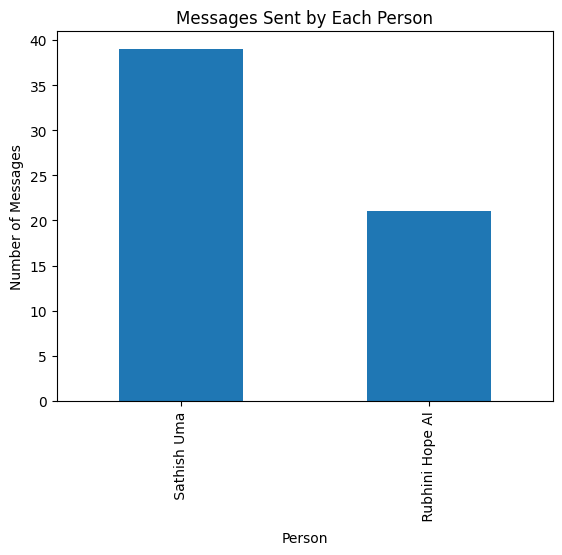

In [42]:
person_count.plot(kind="bar")
plt.title("Messages Sent by Each Person")
plt.xlabel("Person")
plt.ylabel("Number of Messages")

plt.show()

In [43]:
whatsapp_dataset["Date"]=pd.to_datetime(whatsapp_dataset["Date"])
whatsapp_dataset["Day"]=whatsapp_dataset["Date"].dt.day_name()

C:\Users\Sathish\AppData\Local\Temp\ipykernel_8648\868508169.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  whatsapp_dataset["Date"]=pd.to_datetime(whatsapp_dataset["Date"])


Most Active Day

In [44]:
day_count=whatsapp_dataset["Day"].value_counts()
day_count

Day
Monday       30
Tuesday      15
Saturday      8
Wednesday     7
Name: count, dtype: int64

In [45]:
most_active_day=day_count.idxmax()
print("Most Active Day:",most_active_day)

Most Active Day: Monday


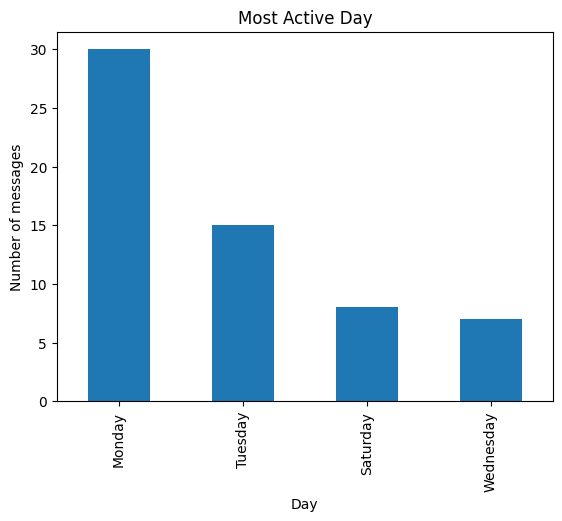

In [46]:
day_count.plot(kind="bar")
plt.title("Most Active Day")
plt.xlabel("Day")
plt.ylabel("Number of messages")
plt.show()

In [52]:
whatsapp_dataset["Time_clean"] = (whatsapp_dataset["Time"]
    .astype(str)
    .str.replace("\u202f", " ", regex=False)
    .str.replace("\xa0", " ", regex=False)
    .str.strip())

whatsapp_dataset["Time_Converted"] = pd.to_datetime(
    whatsapp_dataset["Time_clean"],
    format="%I:%M %p",
    errors="coerce")
    
whatsapp_dataset["Hour"]=(whatsapp_dataset["Time_Converted"].dt.hour)

In [56]:
whatsapp_dataset["Hour"]

0      1
1      1
2      1
3      2
4      2
5      9
6      9
7     10
8     11
9     11
10    11
11    11
12    11
13    11
14    11
15    11
16    11
17    12
18    12
19    12
20    12
21    12
22    12
23    12
24    12
25    12
26    13
27    14
28    14
29    15
30    15
31    15
32    16
33    16
34    16
35    17
36    17
37    18
38    10
39    10
40    10
41    10
42    11
43    11
44    11
45    11
46    12
47    12
48    12
49    12
50    12
51    12
53    12
54    10
55    10
56    11
57    12
58    15
59    15
60    16
Name: Hour, dtype: int32

In [60]:
hour_count=whatsapp_dataset["Hour"].value_counts().sort_index()
hour_count

Hour
1      3
2      2
9      2
10     7
11    14
12    17
13     1
14     2
15     5
16     4
17     2
18     1
Name: count, dtype: int64

In [61]:
most_active_hour = hour_count.idxmax()

print("Most Active Hour:",most_active_hour)

Most Active Hour: 12


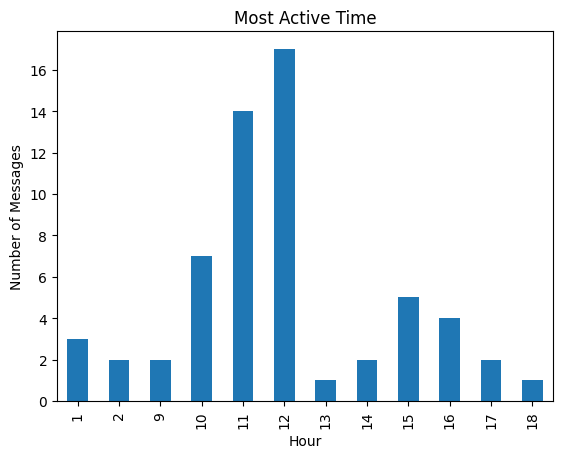

In [62]:
hour_count.plot(kind="bar")
plt.title("Most Active Time")
plt.xlabel("Hour")
plt.ylabel("Number of Messages")
plt.show()